# Movie Recommendation — Bhavish (mine)
Predicting whether a movie should be recommended, using `bhavish_movie_dataset.csv`.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('bhavish_movie_dataset.csv')
df

,movie_id,genre,language,runtime_min,critic_score,audience_score,release_year,num_awards,recommend
0,1,romance,hindi,124,72.6,82.0,2003,0,1
1,2,animation,korean,166,33.6,57.6,1998,1,0
2,3,action,french,154,55.0,35.0,2022,3,0
3,4,romance,french,153,70.8,20.1,2022,2,0
4,5,comedy,hindi,137,50.6,71.5,2001,1,0
...,...,...,...,...,...,...,...,...,...
595,596,action,english,126,92.8,38.1,2018,0,1
596,597,thriller,hindi,160,68.0,89.0,2019,2,1
597,598,horror,korean,149,88.1,62.8,2012,2,1
598,599,horror,spanish,175,60.9,90.4,2012,0,0


In [2]:
df.shape

(600, 9)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   movie_id        600 non-null    int64  
 1   genre           600 non-null    str    
 2   language        600 non-null    str    
 3   runtime_min     600 non-null    int64  
 4   critic_score    600 non-null    float64
 5   audience_score  600 non-null    float64
 6   release_year    600 non-null    int64  
 7   num_awards      600 non-null    int64  
 8   recommend       600 non-null    int64  
dtypes: float64(2), int64(5), str(2)
memory usage: 49.9 KB


In [4]:
df.describe()

,movie_id,runtime_min,critic_score,audience_score,release_year,num_awards,recommend
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,300.500000,131.640000,60.737167,64.979833,2009.441667,1.153333,0.621667
std,173.349358,29.311186,18.495298,15.828520,8.346418,1.049599,0.485376
min,1.000000,80.000000,0.000000,13.700000,1995.000000,0.000000,0.000000
25%,150.750000,106.750000,47.775000,54.200000,2002.000000,0.000000,0.000000
50%,300.500000,133.000000,60.600000,64.800000,2010.000000,1.000000,1.000000
75%,450.250000,157.000000,74.225000,75.925000,2017.000000,2.000000,1.000000
max,600.000000,179.000000,100.000000,100.000000,2023.000000,5.000000,1.000000


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

movie_id          0
genre             0
language          0
runtime_min       0
critic_score      0
audience_score    0
release_year      0
num_awards        0
recommend         0
dtype: int64

## Exploratory data analysis

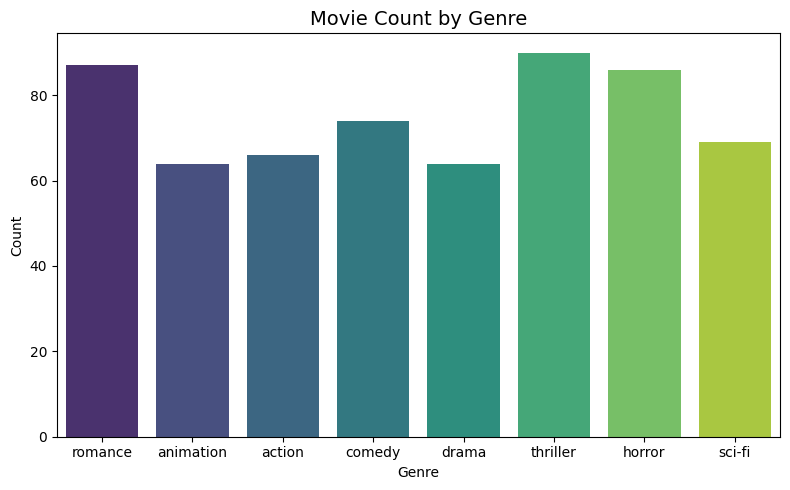

In [7]:
# how many movies per genre
plt.figure(figsize=(8, 5))
sns.countplot(x='genre', data=df, palette='viridis')
plt.title('Movie Count by Genre', fontsize=14)
plt.xlabel('Genre')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

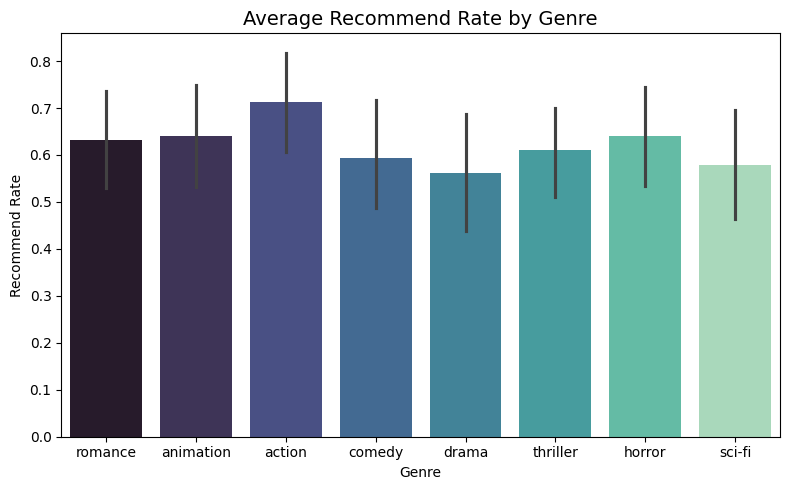

In [8]:
# recommend rate per genre - which genres get recommended more
plt.figure(figsize=(8, 5))
sns.barplot(x='genre', y='recommend', data=df, palette='mako')
plt.title('Average Recommend Rate by Genre', fontsize=14)
plt.xlabel('Genre')
plt.ylabel('Recommend Rate')
plt.tight_layout()
plt.show()

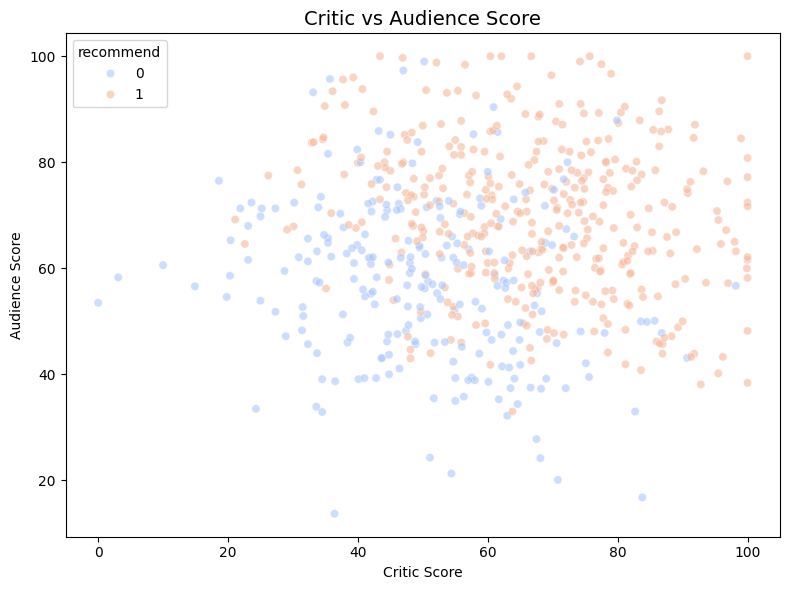

In [9]:
# critic vs audience score, colored by recommend label
plt.figure(figsize=(8, 6))
sns.scatterplot(x='critic_score', y='audience_score', hue='recommend', data=df, palette='coolwarm', alpha=0.6)
plt.title('Critic vs Audience Score', fontsize=14)
plt.xlabel('Critic Score')
plt.ylabel('Audience Score')
plt.tight_layout()
plt.show()

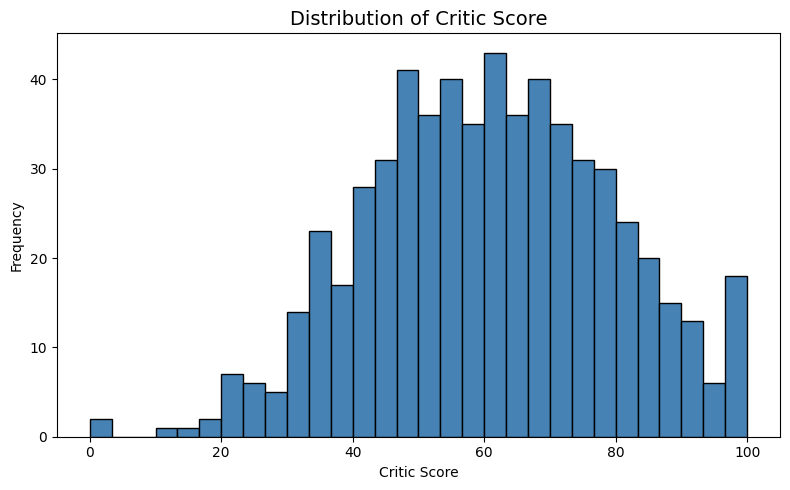

In [10]:
# spread of critic score
plt.figure(figsize=(8, 5))
plt.hist(df['critic_score'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Critic Score', fontsize=14)
plt.xlabel('Critic Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Feature engineering

In [11]:
## FEATURE ENGINEERING
# average of critic and audience score - single quality signal
df['avg_score'] = (df['critic_score'] + df['audience_score']) / 2
# bucket release year into decade
df['decade'] = (df['release_year'] // 10) * 10
# flag for movies that have won at least one award
df['is_award_winner'] = (df['num_awards'] > 0).astype(int)
# how far the critic and audience disagree
df['score_gap'] = (df['critic_score'] - df['audience_score']).abs()
df.head()

,movie_id,genre,language,runtime_min,critic_score,audience_score,release_year,num_awards,recommend,avg_score,decade,is_award_winner,score_gap
0,1,romance,hindi,124,72.6,82.0,2003,0,1,77.30,2000,0,9.4
1,2,animation,korean,166,33.6,57.6,1998,1,0,45.60,1990,1,24.0
2,3,action,french,154,55.0,35.0,2022,3,0,45.00,2020,1,20.0
3,4,romance,french,153,70.8,20.1,2022,2,0,45.45,2020,1,50.7
4,5,comedy,hindi,137,50.6,71.5,2001,1,0,61.05,2000,1,20.9


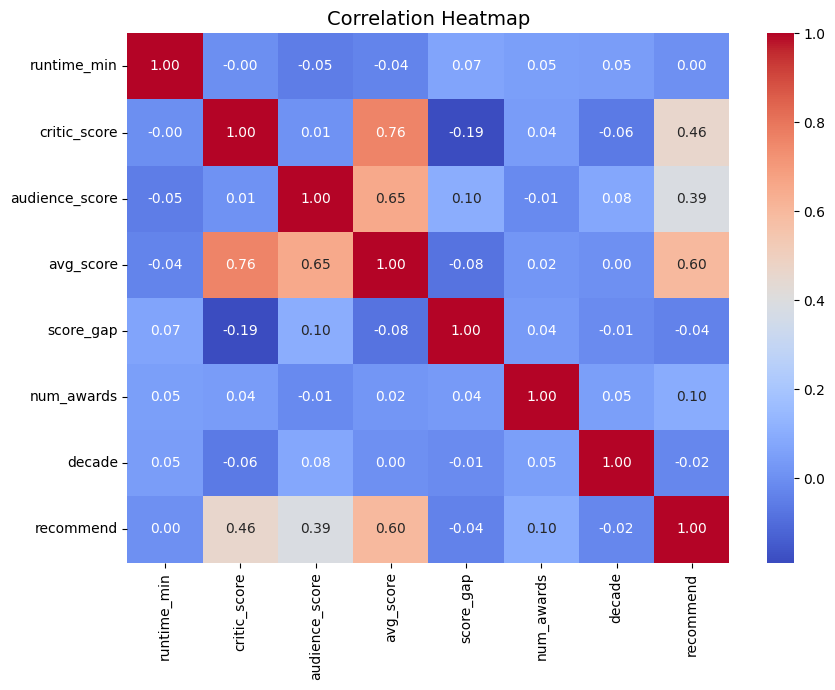

In [12]:
# correlation heatmap of numeric features including the new ones
plt.figure(figsize=(9, 7))
num_cols = ['runtime_min', 'critic_score', 'audience_score', 'avg_score', 'score_gap', 'num_awards', 'decade', 'recommend']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['genre'] = le.fit_transform(df['genre'])
df['language'] = le.fit_transform(df['language'])

## Recommendation target — is this movie worth recommending?

In [14]:
df['recommend'].value_counts()

recommend
1    373
0    227
Name: count, dtype: int64

In [15]:
X = df.drop(['recommend'], axis=1)
y = df['recommend']

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## SVM classifier with hyperparameter tuning
Instead of using fixed SVC parameters, this version runs a small grid search with cross-validation to pick `C`/`gamma`, then reports a fuller classification report and ROC-AUC alongside the confusion matrix.

In [17]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 10], 'gamma': ['scale', 0.01, 0.1]}
grid = GridSearchCV(SVC(kernel='rbf', probability=True, random_state=42), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)

classifier = grid.best_estimator_
y_pred = classifier.predict(X_test)
y_prob = classifier.predict_proba(X_test)[:, 1]

Best params: {'C': 1, 'gamma': 0.01}


In [18]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
print('Accuracy:', accuracy_score(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

Accuracy: 0.8166666666666667
ROC-AUC: 0.8287407407407408
              precision    recall  f1-score   support

           0       0.83      0.64      0.72        45
           1       0.81      0.92      0.86        75

    accuracy                           0.82       120
   macro avg       0.82      0.78      0.79       120
weighted avg       0.82      0.82      0.81       120



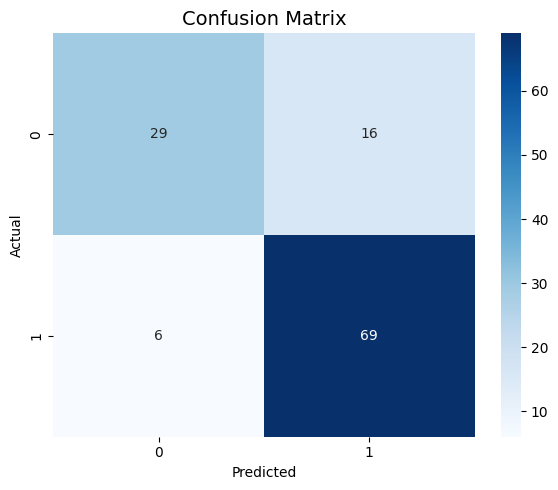

In [19]:
# confusion matrix - simple view of where the model gets it right/wrong
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()